In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
push("Import Libraries")

COMMAND: git add .

COMMAND: git commit -m Import Libraries
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean

COMMAND: git push

Everything up-to-date



In [4]:
%cd /content/supermarket
!pwd
!git status

/content/supermarket
/content/supermarket
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [5]:
%%writefile README.md
# Retail Inventory Analysis

## DS_Day01_04

Retail and FMCG inventory analysis project.

### Objectives

- Identify fast-moving and slow-moving products
- Calculate inventory turnover
- Calculate stock-out frequency
- Analyze promotion impact on sales
- Compare product behaviour across stores
- Recommend inventory levels
- Build and evaluate a Random Forest model

Overwriting README.md


In [6]:
!ls

data  images  models  README.md


In [9]:
import shutil

shutil.copy(
    "/content/retail_inventory_1000_rows.csv",
    "/content/supermarket/data/retail_inventory_1000_rows.csv"
)

print("Dataset copied successfully!")

Dataset copied successfully!


In [10]:
!find . -maxdepth 2 -type f

./data/retail_inventory_1000_rows.csv
./README.md
./.git/index
./.git/config
./.git/packed-refs
./.git/HEAD
./.git/description
./.git/COMMIT_EDITMSG


In [11]:
!git add .
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [12]:
!git commit -m "Initial project setup"

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [13]:
!git push -u origin main

branch 'main' set up to track 'origin/main'.
Everything up-to-date


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [15]:
file_path = "/content/retail_inventory_1000_rows.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1000, 10)


In [16]:
df.head()

,Date,Store_ID,Product_ID,Category,Opening_Stock,Units_Sold,Closing_Stock,Price,Promotion,Holiday
0,2026-01-01,S03,P004,Beverages,37,23,14,79.81,0,0
1,2026-01-01,S03,P011,Dairy,10,10,0,74.62,0,0
2,2026-01-01,S03,P013,Personal Care,44,23,21,121.27,0,0
3,2026-01-01,S04,P002,Beverages,50,30,20,57.72,0,0
4,2026-01-01,S05,P003,Beverages,26,26,0,36.29,1,0


In [17]:
df.tail()

,Date,Store_ID,Product_ID,Category,Opening_Stock,Units_Sold,Closing_Stock,Price,Promotion,Holiday
995,2026-04-10,S06,P002,Beverages,105,50,55,53.17,0,0
996,2026-04-10,S06,P004,Beverages,3,3,0,76.40,1,0
997,2026-04-10,S07,P004,Beverages,35,21,14,82.78,0,0
998,2026-04-10,S09,P004,Beverages,28,12,16,79.89,0,0
999,2026-04-10,S09,P012,Dairy,34,7,27,85.62,1,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           1000 non-null   object 
 1   Store_ID       1000 non-null   object 
 2   Product_ID     1000 non-null   object 
 3   Category       1000 non-null   object 
 4   Opening_Stock  1000 non-null   int64  
 5   Units_Sold     1000 non-null   int64  
 6   Closing_Stock  1000 non-null   int64  
 7   Price          1000 non-null   float64
 8   Promotion      1000 non-null   int64  
 9   Holiday        1000 non-null   int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 78.3+ KB


In [19]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

datetime64[ns]


In [20]:
missing_values = df.isnull().sum()

print(missing_values)

Date             0
Store_ID         0
Product_ID       0
Category         0
Opening_Stock    0
Units_Sold       0
Closing_Stock    0
Price            0
Promotion        0
Holiday          0
dtype: int64


In [21]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

Date             0.0
Store_ID         0.0
Product_ID       0.0
Category         0.0
Opening_Stock    0.0
Units_Sold       0.0
Closing_Stock    0.0
Price            0.0
Promotion        0.0
Holiday          0.0
dtype: float64


In [22]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [23]:
df["Calculated_Closing_Stock"] = (
    df["Opening_Stock"] - df["Units_Sold"]
)

invalid_stock = df[
    df["Calculated_Closing_Stock"] != df["Closing_Stock"]
]

print("Rows with incorrect stock calculation:", len(invalid_stock))

Rows with incorrect stock calculation: 0


In [24]:
invalid_sales = df[df["Units_Sold"] > df["Opening_Stock"]]

print("Rows where Units Sold > Opening Stock:", len(invalid_sales))

Rows where Units Sold > Opening Stock: 0


In [25]:
print("Negative Opening Stock:",
      (df["Opening_Stock"] < 0).sum())

print("Negative Units Sold:",
      (df["Units_Sold"] < 0).sum())

print("Negative Closing Stock:",
      (df["Closing_Stock"] < 0).sum())

print("Negative Price:",
      (df["Price"] < 0).sum())

Negative Opening Stock: 0
Negative Units Sold: 0
Negative Closing Stock: 0
Negative Price: 0


In [26]:
print("Promotion values:",
      df["Promotion"].unique())

print("Holiday values:",
      df["Holiday"].unique())

valid_promotion = df["Promotion"].isin([0, 1]).all()
valid_holiday = df["Holiday"].isin([0, 1]).all()

print("Promotion column valid:", valid_promotion)
print("Holiday column valid:", valid_holiday)

Promotion values: [0 1]
Holiday values: [0 1]
Promotion column valid: True
Holiday column valid: True


In [27]:
print("Number of stores:", df["Store_ID"].nunique())
print("Number of products:", df["Product_ID"].nunique())
print("Number of categories:", df["Category"].nunique())

print("\nCategories:")
print(df["Category"].unique())

Number of stores: 10
Number of products: 20
Number of categories: 5

Categories:
['Beverages' 'Dairy' 'Personal Care' 'Snacks' 'Household']


In [28]:
df.drop(columns=["Calculated_Closing_Stock"], inplace=True)

In [29]:
print("========== FINAL DATA VALIDATION ==========")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nInvalid stock calculations:")
print(
    (df["Closing_Stock"] !=
     (df["Opening_Stock"] - df["Units_Sold"])).sum()
)

print("\nInvalid sales:")
print((df["Units_Sold"] > df["Opening_Stock"]).sum())

print("\nNegative values:")
print(
    ((df["Opening_Stock"] < 0) |
     (df["Units_Sold"] < 0) |
     (df["Closing_Stock"] < 0) |
     (df["Price"] < 0)).sum()
)

print("\n===========================================")

========== FINAL DATA VALIDATION ==========
Rows: 1000
Columns: 10

Missing values:
0

Duplicate rows:
0

Invalid stock calculations:
0

Invalid sales:
0

Negative values:
0



In [30]:
%cd /content/supermarket

/content/supermarket


In [31]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [32]:
import shutil
import os

os.makedirs("/content/supermarket/data", exist_ok=True)

shutil.copy(
    "/content/retail_inventory_1000_rows.csv",
    "/content/supermarket/data/retail_inventory_1000_rows.csv"
)

print("Dataset copied!")

Dataset copied!


In [33]:
%cd /content/supermarket
!git status

/content/supermarket
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [34]:
!git add .
!git commit -m "Add retail inventory dataset and Phase 2 validation"
!git push origin main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


In [35]:
# Make sure the dataset is loaded

df = pd.read_csv("/content/retail_inventory_1000_rows.csv")

df["Date"] = pd.to_datetime(df["Date"])

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 10)


,Date,Store_ID,Product_ID,Category,Opening_Stock,Units_Sold,Closing_Stock,Price,Promotion,Holiday
0,2026-01-01,S03,P004,Beverages,37,23,14,79.81,0,0
1,2026-01-01,S03,P011,Dairy,10,10,0,74.62,0,0
2,2026-01-01,S03,P013,Personal Care,44,23,21,121.27,0,0
3,2026-01-01,S04,P002,Beverages,50,30,20,57.72,0,0
4,2026-01-01,S05,P003,Beverages,26,26,0,36.29,1,0


In [36]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nStores:", df["Store_ID"].nunique())
print("Products:", df["Product_ID"].nunique())
print("Categories:", df["Category"].nunique())

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

Number of rows: 1000
Number of columns: 10

Stores: 10
Products: 20
Categories: 5

Date range:
2026-01-01 00:00:00 to 2026-04-10 00:00:00


In [37]:
df.describe()

,Date,Opening_Stock,Units_Sold,Closing_Stock,Price,Promotion,Holiday
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2026-02-18 23:44:09.600000,40.787000,24.434000,16.353000,99.015350,0.286000,0.073000
min,2026-01-01 00:00:00,1.000000,1.000000,0.000000,23.790000,0.000000,0.000000
25%,2026-01-24 00:00:00,18.000000,11.000000,2.000000,49.500000,0.000000,0.000000
50%,2026-02-19 00:00:00,34.500000,21.000000,12.000000,82.480000,0.000000,0.000000
75%,2026-03-17 00:00:00,57.000000,34.000000,25.000000,148.902500,1.000000,0.000000
max,2026-04-10 00:00:00,211.000000,91.000000,134.000000,230.880000,1.000000,1.000000
std,NaN,29.340868,16.486584,17.452937,58.081414,0.452115,0.260267


In [38]:
summary = df[
    [
        "Opening_Stock",
        "Units_Sold",
        "Closing_Stock",
        "Price"
    ]
].describe().T

summary

,count,mean,std,min,25%,50%,75%,max
Opening_Stock,1000.0,40.78700,29.340868,1.00,18.0,34.50,57.0000,211.00
Units_Sold,1000.0,24.43400,16.486584,1.00,11.0,21.00,34.0000,91.00
Closing_Stock,1000.0,16.35300,17.452937,0.00,2.0,12.00,25.0000,134.00
Price,1000.0,99.01535,58.081414,23.79,49.5,82.48,148.9025,230.88


In [39]:
product_sales = (
    df.groupby("Product_ID")["Units_Sold"]
    .agg(["sum", "mean", "count"])
    .sort_values("sum", ascending=False)
)

product_sales

,sum,mean,count
Product_ID,,,
P009,2160,42.352941,51
P005,2132,48.454545,44
P002,2064,42.122449,49
P006,2047,40.137255,51
P001,1957,48.925000,40
P013,1528,30.560000,50
P003,1435,35.000000,41
P010,1415,31.444444,45
P007,1321,28.106383,47


In [40]:
product_sales = (
    df.groupby("Product_ID")["Units_Sold"]
    .agg(["sum", "mean", "count"])
    .sort_values("sum", ascending=False)
)

product_sales

,sum,mean,count
Product_ID,,,
P009,2160,42.352941,51
P005,2132,48.454545,44
P002,2064,42.122449,49
P006,2047,40.137255,51
P001,1957,48.925000,40
P013,1528,30.560000,50
P003,1435,35.000000,41
P010,1415,31.444444,45
P007,1321,28.106383,47


In [41]:
product_sales.columns = [
    "Total_Units_Sold",
    "Average_Daily_Sales",
    "Days_Observed"
]

product_sales

,Total_Units_Sold,Average_Daily_Sales,Days_Observed
Product_ID,,,
P009,2160,42.352941,51
P005,2132,48.454545,44
P002,2064,42.122449,49
P006,2047,40.137255,51
P001,1957,48.925000,40
P013,1528,30.560000,50
P003,1435,35.000000,41
P010,1415,31.444444,45
P007,1321,28.106383,47


In [42]:
fast_moving = product_sales.sort_values(
    "Average_Daily_Sales",
    ascending=False
)

fast_moving.head(5)

,Total_Units_Sold,Average_Daily_Sales,Days_Observed
Product_ID,,,
P001,1957,48.925000,40
P005,2132,48.454545,44
P009,2160,42.352941,51
P002,2064,42.122449,49
P006,2047,40.137255,51


In [43]:
slow_moving = product_sales.sort_values(
    "Average_Daily_Sales",
    ascending=True
)

print("Top 5 Slow-Moving Products:")
print(
    slow_moving[
        ["Total_Units_Sold", "Average_Daily_Sales"]
    ].head(5)
)

Top 5 Slow-Moving Products:
            Total_Units_Sold  Average_Daily_Sales
Product_ID                                       
P020                     220             4.583333
P016                     352             7.333333
P012                     628            10.129032
P019                     686            10.718750
P008                     472            10.976744


In [44]:
category_sales = (
    df.groupby("Category")["Units_Sold"]
    .agg(["sum", "mean"])
    .sort_values("sum", ascending=False)
)

category_sales.columns = [
    "Total_Units_Sold",
    "Average_Daily_Sales"
]

category_sales

,Total_Units_Sold,Average_Daily_Sales
Category,,
Beverages,6389,35.893258
Snacks,5972,32.281081
Dairy,5355,25.379147
Personal Care,3880,18.046512
Household,2838,13.450237


In [45]:
store_sales = (
    df.groupby("Store_ID")["Units_Sold"]
    .agg(["sum", "mean"])
    .sort_values("sum", ascending=False)
)

store_sales.columns = [
    "Total_Units_Sold",
    "Average_Daily_Sales"
]

store_sales

,Total_Units_Sold,Average_Daily_Sales
Store_ID,,
S02,3056,28.830189
S01,3011,31.694737
S07,2992,28.226415
S06,2959,30.822917
S05,2612,22.135593
S08,2373,21.572727
S03,2346,27.279070
S04,1915,21.043956
S09,1691,18.380435


In [46]:
promotion_sales = (
    df.groupby("Promotion")["Units_Sold"]
    .agg(["count", "sum", "mean"])
)

promotion_sales

,count,sum,mean
Promotion,,,
0,714,15800,22.128852
1,286,8634,30.188811


In [47]:
no_promo_sales = df[df["Promotion"] == 0]["Units_Sold"].mean()
promo_sales = df[df["Promotion"] == 1]["Units_Sold"].mean()

uplift = ((promo_sales - no_promo_sales) / no_promo_sales) * 100

print(f"Average sales without promotion: {no_promo_sales:.2f}")
print(f"Average sales with promotion: {promo_sales:.2f}")
print(f"Sales uplift from promotion: {uplift:.2f}%")

Average sales without promotion: 22.13
Average sales with promotion: 30.19
Sales uplift from promotion: 36.42%


In [48]:
holiday_sales = (
    df.groupby("Holiday")["Units_Sold"]
    .agg(["count", "sum", "mean"])
)

holiday_sales

,count,sum,mean
Holiday,,,
0,927,22569,24.346278
1,73,1865,25.547945


In [49]:
normal_sales = df[df["Holiday"] == 0]["Units_Sold"].mean()
holiday_sales_avg = df[df["Holiday"] == 1]["Units_Sold"].mean()

holiday_uplift = (
    (holiday_sales_avg - normal_sales) /
    normal_sales
) * 100

print(f"Average sales on normal days: {normal_sales:.2f}")
print(f"Average sales on holidays: {holiday_sales_avg:.2f}")
print(f"Holiday sales uplift: {holiday_uplift:.2f}%")

Average sales on normal days: 24.35
Average sales on holidays: 25.55
Holiday sales uplift: 4.94%


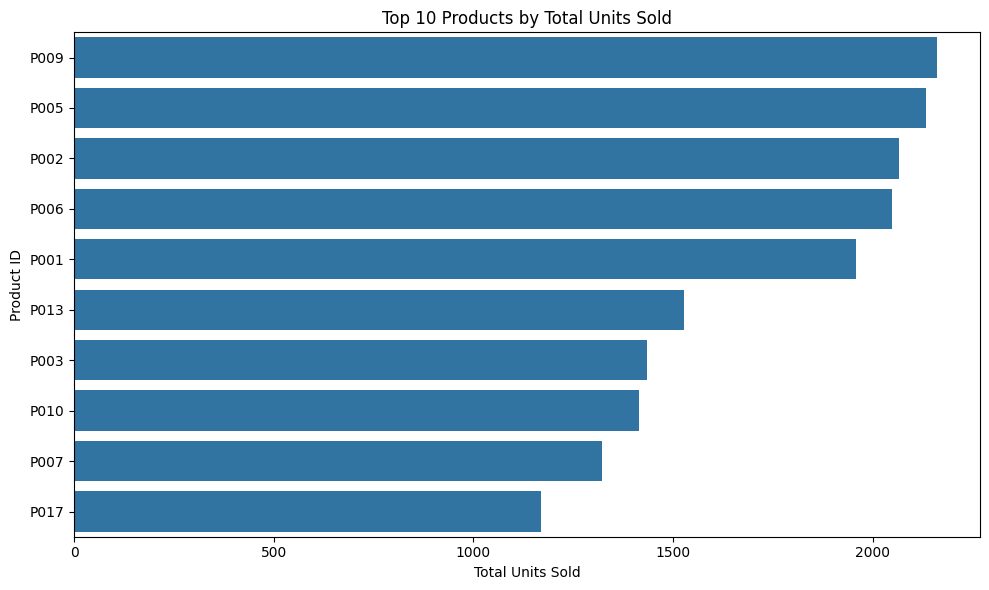

In [50]:
plt.figure(figsize=(10, 6))

top_products = (
    df.groupby("Product_ID")["Units_Sold"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Total Units Sold")
plt.xlabel("Total Units Sold")
plt.ylabel("Product ID")
plt.tight_layout()

plt.savefig(
    "/content/top_10_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

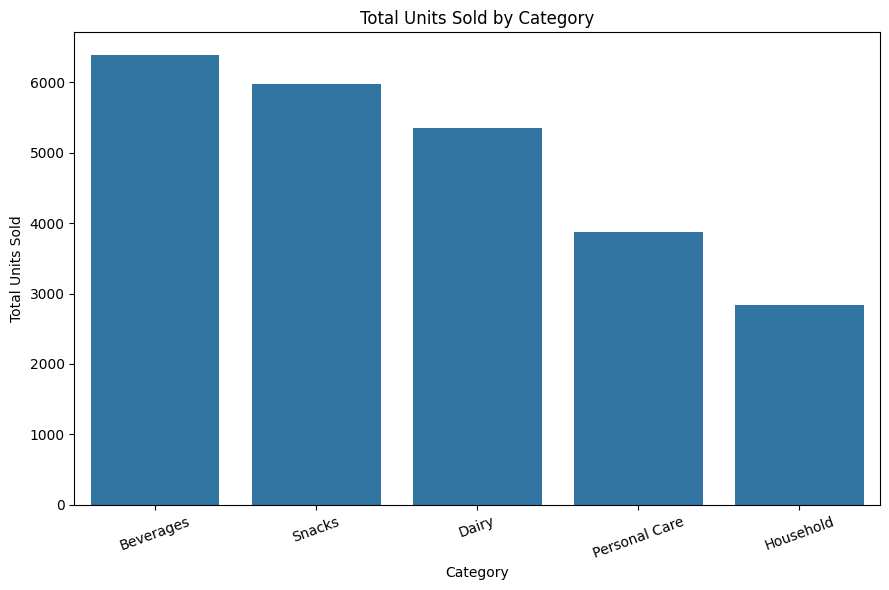

In [51]:
plt.figure(figsize=(9, 6))

category_plot = (
    df.groupby("Category")["Units_Sold"]
    .sum()
    .sort_values(ascending=False)
)

sns.barplot(
    x=category_plot.index,
    y=category_plot.values
)

plt.title("Total Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "/content/category_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

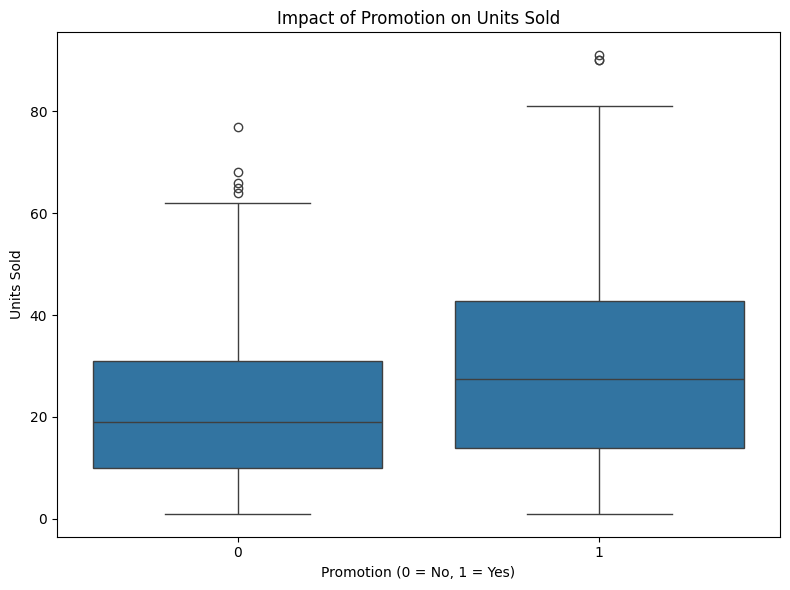

In [52]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x="Promotion",
    y="Units_Sold",
    data=df
)

plt.title("Impact of Promotion on Units Sold")
plt.xlabel("Promotion (0 = No, 1 = Yes)")
plt.ylabel("Units Sold")

plt.tight_layout()

plt.savefig(
    "/content/promotion_impact.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

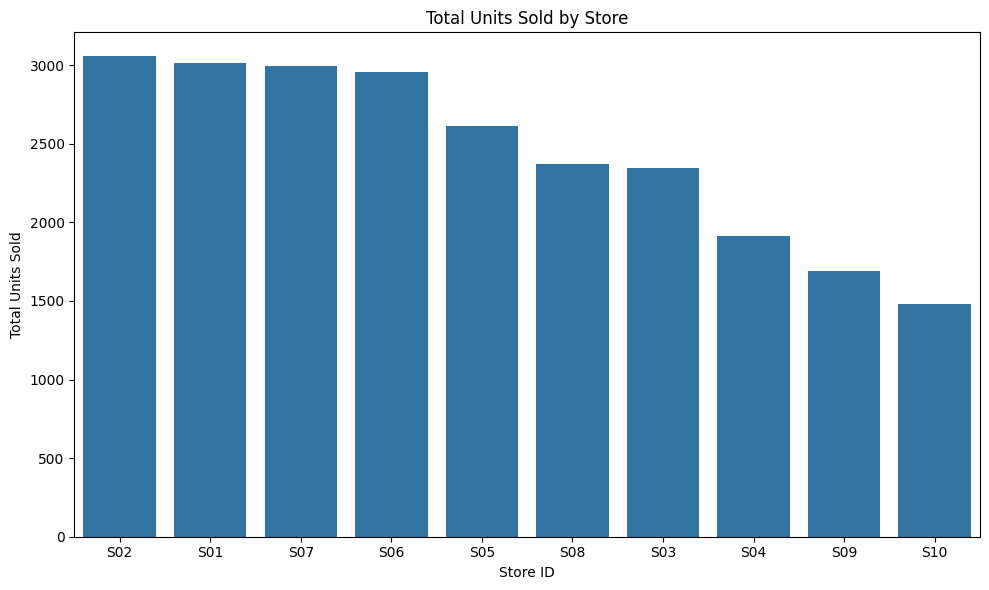

In [53]:
plt.figure(figsize=(10, 6))

store_plot = (
    df.groupby("Store_ID")["Units_Sold"]
    .sum()
    .sort_values(ascending=False)
)

sns.barplot(
    x=store_plot.index,
    y=store_plot.values
)

plt.title("Total Units Sold by Store")
plt.xlabel("Store ID")
plt.ylabel("Total Units Sold")

plt.tight_layout()

plt.savefig(
    "/content/store_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

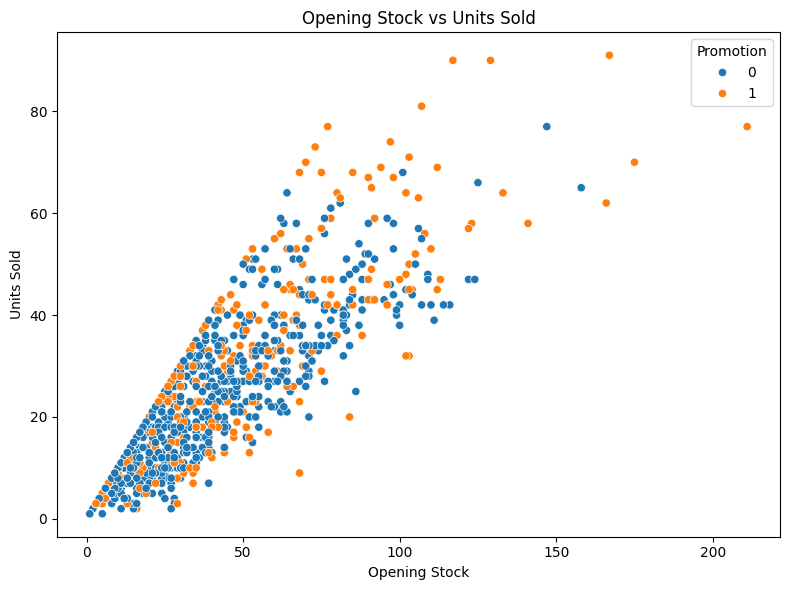

In [54]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Opening_Stock",
    y="Units_Sold",
    hue="Promotion"
)

plt.title("Opening Stock vs Units Sold")
plt.xlabel("Opening Stock")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

In [55]:
import shutil
import os

os.makedirs("/content/supermarket/images", exist_ok=True)

for file in [
    "top_10_products.png",
    "category_sales.png",
    "promotion_impact.png",
    "store_sales.png"
]:
    shutil.copy(
        f"/content/{file}",
        f"/content/supermarket/images/{file}"
    )

print("All four visualizations copied to the project.")

All four visualizations copied to the project.


In [56]:
import shutil
import os

os.makedirs("/content/supermarket/images", exist_ok=True)

for file in [
    "top_10_products.png",
    "category_sales.png",
    "promotion_impact.png",
    "store_sales.png"
]:
    shutil.copy(
        f"/content/{file}",
        f"/content/supermarket/images/{file}"
    )

print("All four visualizations copied to the project.")

All four visualizations copied to the project.


In [58]:
df["Average_Inventory"] = (df["Opening_Stock"] + df["Closing_Stock"]) / 2

product_inventory = df.groupby("Product_ID").agg(
    Total_Units_Sold=("Units_Sold", "sum"),
    Average_Daily_Sales=("Units_Sold", "mean"),
    Average_Inventory=("Average_Inventory", "mean"),
    Stockout_Days=("Closing_Stock", lambda x: (x == 0).sum()),
    Total_Days=("Product_ID", "count")
)

product_inventory["Inventory_Turnover"] = (
    product_inventory["Total_Units_Sold"] /
    product_inventory["Average_Inventory"]
)

product_inventory["Stockout_Frequency"] = (
    product_inventory["Stockout_Days"] /
    product_inventory["Total_Days"]
) * 100

product_inventory = product_inventory.sort_values(
    "Total_Units_Sold",
    ascending=False
)

product_inventory

,Total_Units_Sold,Average_Daily_Sales,Average_Inventory,Stockout_Days,Total_Days,Inventory_Turnover,Stockout_Frequency
Product_ID,,,,,,,
P009,2160,42.352941,52.313725,5,51,41.289355,9.803922
P005,2132,48.454545,51.136364,7,44,41.692444,15.909091
P002,2064,42.122449,45.224490,8,49,45.638989,16.326531
P006,2047,40.137255,44.107843,4,51,46.408980,7.843137
P001,1957,48.925000,54.662500,6,40,35.801509,15.000000
P013,1528,30.560000,39.760000,4,50,38.430584,8.000000
P003,1435,35.000000,39.231707,8,41,36.577557,19.512195
P010,1415,31.444444,31.988889,12,45,44.234109,26.666667
P007,1321,28.106383,32.776596,6,47,40.303148,12.765957


In [59]:
fast_products = product_inventory.sort_values(
    "Average_Daily_Sales",
    ascending=False
).head(5)

fast_products[
    [
        "Total_Units_Sold",
        "Average_Daily_Sales",
        "Inventory_Turnover",
        "Stockout_Frequency"
    ]
]

,Total_Units_Sold,Average_Daily_Sales,Inventory_Turnover,Stockout_Frequency
Product_ID,,,,
P001,1957,48.925000,35.801509,15.000000
P005,2132,48.454545,41.692444,15.909091
P009,2160,42.352941,41.289355,9.803922
P002,2064,42.122449,45.638989,16.326531
P006,2047,40.137255,46.408980,7.843137


In [60]:
slow_products = product_inventory.sort_values(
    "Average_Daily_Sales"
).head(5)

slow_products[
    [
        "Total_Units_Sold",
        "Average_Daily_Sales",
        "Inventory_Turnover",
        "Stockout_Frequency"
    ]
]

,Total_Units_Sold,Average_Daily_Sales,Inventory_Turnover,Stockout_Frequency
Product_ID,,,,
P020,220,4.583333,32.097264,43.750000
P016,352,7.333333,32.807767,33.333333
P012,628,10.129032,45.274419,27.419355
P019,686,10.718750,48.352423,32.812500
P008,472,10.976744,36.503597,32.558140


In [61]:
stockout_products = product_inventory.sort_values(
    "Stockout_Frequency",
    ascending=False
).head(5)

stockout_products[
    [
        "Total_Units_Sold",
        "Average_Daily_Sales",
        "Inventory_Turnover",
        "Stockout_Days",
        "Stockout_Frequency"
    ]
]

,Total_Units_Sold,Average_Daily_Sales,Inventory_Turnover,Stockout_Days,Stockout_Frequency
Product_ID,,,,,
P020,220,4.583333,32.097264,21,43.750000
P018,763,15.895833,38.899628,16,33.333333
P016,352,7.333333,32.807767,16,33.333333
P019,686,10.718750,48.352423,21,32.812500
P008,472,10.976744,36.503597,14,32.558140


In [63]:
store_inventory = df.groupby("Store_ID").agg(
    Total_Units_Sold=("Units_Sold", "sum"),
    Average_Daily_Sales=("Units_Sold", "mean"),
    Average_Inventory=("Average_Inventory", "mean"),
    Stockout_Days=("Closing_Stock", lambda x: (x == 0).sum()),
    Total_Days=("Store_ID", "count")
)

store_inventory["Stockout_Frequency"] = (
    store_inventory["Stockout_Days"] /
    store_inventory["Total_Days"]
) * 100

store_inventory.sort_values(
    "Total_Units_Sold",
    ascending=False
)

,Total_Units_Sold,Average_Daily_Sales,Average_Inventory,Stockout_Days,Total_Days,Stockout_Frequency
Store_ID,,,,,,
S02,3056,28.830189,34.377358,20,106,18.867925
S01,3011,31.694737,38.615789,17,95,17.894737
S07,2992,28.226415,33.066038,22,106,20.754717
S06,2959,30.822917,34.734375,20,96,20.833333
S05,2612,22.135593,28.533898,21,118,17.796610
S08,2373,21.572727,23.586364,31,110,28.181818
S03,2346,27.279070,32.267442,17,86,19.767442
S04,1915,21.043956,24.456044,18,91,19.780220
S09,1691,18.380435,19.451087,25,92,27.173913


In [64]:
promotion_inventory = df.groupby("Promotion").agg(
    Average_Sales=("Units_Sold", "mean"),
    Average_Opening_Stock=("Opening_Stock", "mean"),
    Average_Closing_Stock=("Closing_Stock", "mean"),
    Stockout_Rate=("Closing_Stock", lambda x: (x == 0).mean() * 100)
)

promotion_inventory.index = [
    "No Promotion",
    "Promotion"
]

promotion_inventory

,Average_Sales,Average_Opening_Stock,Average_Closing_Stock,Stockout_Rate
No Promotion,22.128852,37.487395,15.358543,21.428571
Promotion,30.188811,49.024476,18.835664,24.825175


In [65]:
def inventory_action(row):
    if (
        row["Average_Daily_Sales"] >= product_inventory["Average_Daily_Sales"].median()
        and row["Stockout_Frequency"] >= 15
    ):
        return "Increase Inventory"

    elif (
        row["Average_Daily_Sales"] < product_inventory["Average_Daily_Sales"].median()
        and row["Stockout_Frequency"] < 5
    ):
        return "Reduce Inventory"

    else:
        return "Maintain Inventory"

product_inventory["Recommended_Action"] = product_inventory.apply(
    inventory_action,
    axis=1
)

In [66]:
product_inventory[
    [
        "Total_Units_Sold",
        "Average_Daily_Sales",
        "Inventory_Turnover",
        "Stockout_Frequency",
        "Recommended_Action"
    ]
]

,Total_Units_Sold,Average_Daily_Sales,Inventory_Turnover,Stockout_Frequency,Recommended_Action
Product_ID,,,,,
P009,2160,42.352941,41.289355,9.803922,Maintain Inventory
P005,2132,48.454545,41.692444,15.909091,Increase Inventory
P002,2064,42.122449,45.638989,16.326531,Increase Inventory
P006,2047,40.137255,46.408980,7.843137,Maintain Inventory
P001,1957,48.925000,35.801509,15.000000,Increase Inventory
P013,1528,30.560000,38.430584,8.000000,Maintain Inventory
P003,1435,35.000000,36.577557,19.512195,Increase Inventory
P010,1415,31.444444,44.234109,26.666667,Increase Inventory
P007,1321,28.106383,40.303148,12.765957,Maintain Inventory


In [67]:
product_inventory["Recommended_Action"].value_counts()

,count
Recommended_Action,
Maintain Inventory,14
Increase Inventory,6


In [68]:
final_inventory = product_inventory[
    [
        "Total_Units_Sold",
        "Average_Daily_Sales",
        "Average_Inventory",
        "Inventory_Turnover",
        "Stockout_Days",
        "Stockout_Frequency",
        "Recommended_Action"
    ]
].sort_values(
    "Inventory_Turnover",
    ascending=False
)

final_inventory

,Total_Units_Sold,Average_Daily_Sales,Average_Inventory,Inventory_Turnover,Stockout_Days,Stockout_Frequency,Recommended_Action
Product_ID,,,,,,,
P015,867,13.761905,16.071429,53.946667,19,30.158730,Maintain Inventory
P019,686,10.718750,14.187500,48.352423,21,32.812500,Maintain Inventory
P006,2047,40.137255,44.107843,46.408980,4,7.843137,Maintain Inventory
P011,1152,21.735849,25.150943,45.803451,10,18.867925,Maintain Inventory
P002,2064,42.122449,45.224490,45.638989,8,16.326531,Increase Inventory
P012,628,10.129032,13.870968,45.274419,17,27.419355,Maintain Inventory
P010,1415,31.444444,31.988889,44.234109,12,26.666667,Increase Inventory
P014,1133,20.981481,26.120370,43.376108,10,18.518519,Maintain Inventory
P017,1169,22.921569,27.401961,42.661181,8,15.686275,Increase Inventory


In [70]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_df = df.copy()

# Date-based features
model_df["Day"] = model_df["Date"].dt.day
model_df["Month"] = model_df["Date"].dt.month
model_df["DayOfWeek"] = model_df["Date"].dt.dayofweek

# One-hot encode categorical variables
model_df = pd.get_dummies(
    model_df,
    columns=["Store_ID", "Product_ID", "Category"],
    drop_first=True
)

In [71]:
X = model_df.drop(
    columns=["Date", "Units_Sold", "Closing_Stock"]
)

y = model_df["Units_Sold"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (1000, 40)
Target: (1000,)


In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 800
Testing rows: 200


In [73]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [74]:
y_pred = rf_model.predict(X_test)

print("Predictions generated:", len(y_pred))

Predictions generated: 200


In [75]:
mae = mean_absolute_error(y_test, y_pred)

In [76]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [77]:
r2 = r2_score(y_test, y_pred)

In [78]:
print("========== MODEL EVALUATION ==========")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

========== MODEL EVALUATION ==========
MAE  : 2.27
RMSE : 3.46
R²   : 0.9451


In [79]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

,0
Opening_Stock,0.788599
Average_Inventory,0.084662
Price,0.078765
Promotion,0.008570
Day,0.008398
DayOfWeek,0.005755
Month,0.003601
Product_ID_P007,0.001792
Product_ID_P013,0.001711
Store_ID_S06,0.001555


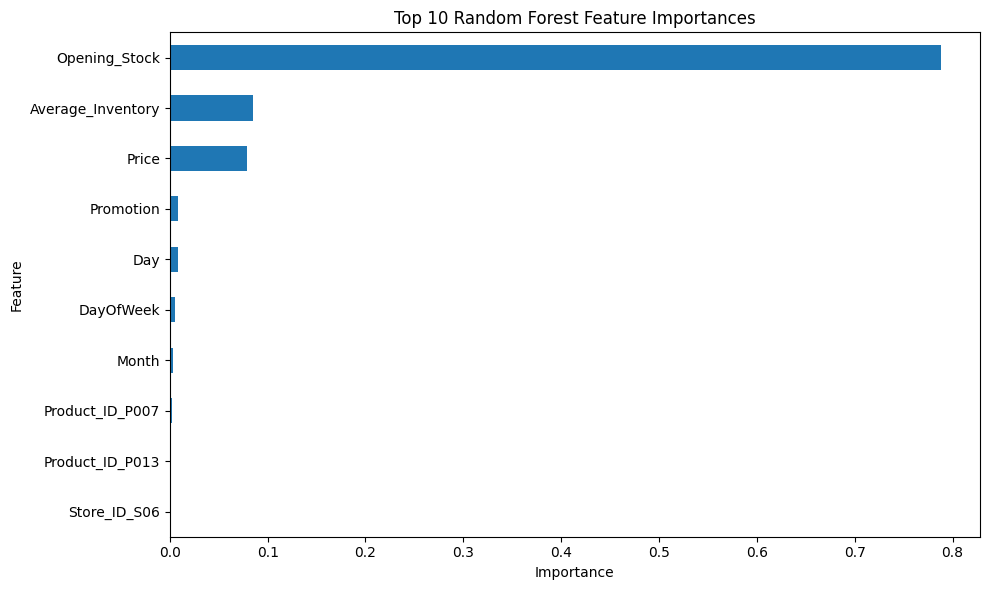

In [80]:
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

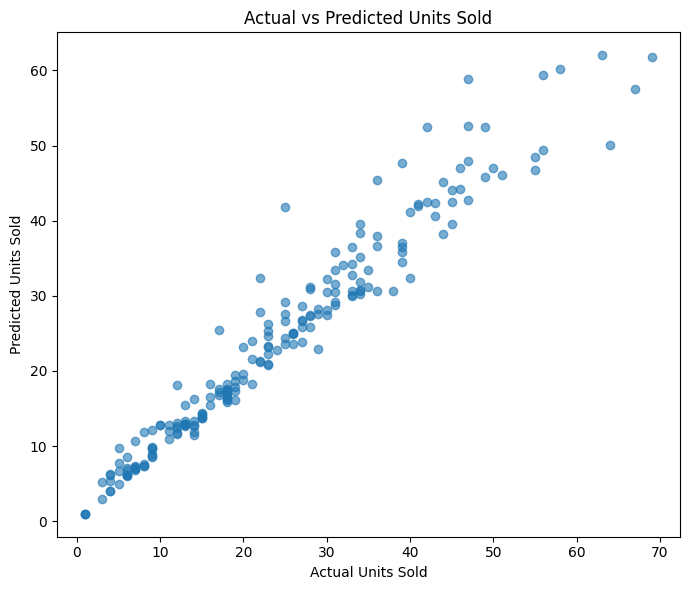

In [81]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title("Actual vs Predicted Units Sold")

plt.tight_layout()
plt.show()

In [82]:
import joblib
import os

os.makedirs("/content/supermarket/models", exist_ok=True)

joblib.dump(
    rf_model,
    "/content/supermarket/models/random_forest_inventory_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [83]:
print("========== FINAL PRODUCT ANALYSIS ==========")

top_product = product_inventory["Total_Units_Sold"].idxmax()
slow_product = product_inventory["Total_Units_Sold"].idxmin()
highest_turnover = product_inventory["Inventory_Turnover"].idxmax()
highest_stockout = product_inventory["Stockout_Frequency"].idxmax()

print(f"Highest-selling product: {top_product}")
print(f"Slowest-selling product: {slow_product}")
print(f"Highest inventory-turnover product: {highest_turnover}")
print(f"Highest stock-out frequency: {highest_stockout}")

========== FINAL PRODUCT ANALYSIS ==========
Highest-selling product: P009
Slowest-selling product: P020
Highest inventory-turnover product: P015
Highest stock-out frequency: P020


In [84]:
print("\n========== TOP 5 FAST-MOVING ==========")
display(
    product_inventory.sort_values(
        "Average_Daily_Sales",
        ascending=False
    ).head(5)
)

print("\n========== TOP 5 SLOW-MOVING ==========")
display(
    product_inventory.sort_values(
        "Average_Daily_Sales"
    ).head(5)
)

print("\n========== TOP 5 STOCK-OUT PRODUCTS ==========")
display(
    product_inventory.sort_values(
        "Stockout_Frequency",
        ascending=False
    ).head(5)
)


========== TOP 5 FAST-MOVING ==========


,Total_Units_Sold,Average_Daily_Sales,Average_Inventory,Stockout_Days,Total_Days,Inventory_Turnover,Stockout_Frequency,Recommended_Action
Product_ID,,,,,,,,
P001,1957,48.925000,54.662500,6,40,35.801509,15.000000,Increase Inventory
P005,2132,48.454545,51.136364,7,44,41.692444,15.909091,Increase Inventory
P009,2160,42.352941,52.313725,5,51,41.289355,9.803922,Maintain Inventory
P002,2064,42.122449,45.224490,8,49,45.638989,16.326531,Increase Inventory
P006,2047,40.137255,44.107843,4,51,46.408980,7.843137,Maintain Inventory



========== TOP 5 SLOW-MOVING ==========


,Total_Units_Sold,Average_Daily_Sales,Average_Inventory,Stockout_Days,Total_Days,Inventory_Turnover,Stockout_Frequency,Recommended_Action
Product_ID,,,,,,,,
P020,220,4.583333,6.854167,21,48,32.097264,43.750000,Maintain Inventory
P016,352,7.333333,10.729167,16,48,32.807767,33.333333,Maintain Inventory
P012,628,10.129032,13.870968,17,62,45.274419,27.419355,Maintain Inventory
P019,686,10.718750,14.187500,21,64,48.352423,32.812500,Maintain Inventory
P008,472,10.976744,12.930233,14,43,36.503597,32.558140,Maintain Inventory



========== TOP 5 STOCK-OUT PRODUCTS ==========


,Total_Units_Sold,Average_Daily_Sales,Average_Inventory,Stockout_Days,Total_Days,Inventory_Turnover,Stockout_Frequency,Recommended_Action
Product_ID,,,,,,,,
P020,220,4.583333,6.854167,21,48,32.097264,43.750000,Maintain Inventory
P018,763,15.895833,19.614583,16,48,38.899628,33.333333,Maintain Inventory
P016,352,7.333333,10.729167,16,48,32.807767,33.333333,Maintain Inventory
P019,686,10.718750,14.187500,21,64,48.352423,32.812500,Maintain Inventory
P008,472,10.976744,12.930233,14,43,36.503597,32.558140,Maintain Inventory


In [85]:
promotion_uplift = (
    (
        promotion_inventory.loc["Promotion", "Average_Sales"]
        - promotion_inventory.loc["No Promotion", "Average_Sales"]
    )
    / promotion_inventory.loc["No Promotion", "Average_Sales"]
) * 100

print(f"Promotion sales uplift: {promotion_uplift:.2f}%")

Promotion sales uplift: 36.42%


In [86]:
best_sales_store = store_inventory["Total_Units_Sold"].idxmax()
highest_stockout_store = store_inventory["Stockout_Frequency"].idxmax()

print("Highest-sales store:", best_sales_store)
print("Highest stock-out-frequency store:", highest_stockout_store)

display(
    store_inventory.sort_values(
        "Total_Units_Sold",
        ascending=False
    )
)

Highest-sales store: S02
Highest stock-out-frequency store: S10


,Total_Units_Sold,Average_Daily_Sales,Average_Inventory,Stockout_Days,Total_Days,Stockout_Frequency
Store_ID,,,,,,
S02,3056,28.830189,34.377358,20,106,18.867925
S01,3011,31.694737,38.615789,17,95,17.894737
S07,2992,28.226415,33.066038,22,106,20.754717
S06,2959,30.822917,34.734375,20,96,20.833333
S05,2612,22.135593,28.533898,21,118,17.796610
S08,2373,21.572727,23.586364,31,110,28.181818
S03,2346,27.279070,32.267442,17,86,19.767442
S04,1915,21.043956,24.456044,18,91,19.780220
S09,1691,18.380435,19.451087,25,92,27.173913


In [87]:
final_inventory = product_inventory[
    [
        "Total_Units_Sold",
        "Average_Daily_Sales",
        "Average_Inventory",
        "Inventory_Turnover",
        "Stockout_Days",
        "Stockout_Frequency",
        "Recommended_Action"
    ]
].sort_values(
    "Total_Units_Sold",
    ascending=False
)

display(final_inventory)

,Total_Units_Sold,Average_Daily_Sales,Average_Inventory,Inventory_Turnover,Stockout_Days,Stockout_Frequency,Recommended_Action
Product_ID,,,,,,,
P009,2160,42.352941,52.313725,41.289355,5,9.803922,Maintain Inventory
P005,2132,48.454545,51.136364,41.692444,7,15.909091,Increase Inventory
P002,2064,42.122449,45.224490,45.638989,8,16.326531,Increase Inventory
P006,2047,40.137255,44.107843,46.408980,4,7.843137,Maintain Inventory
P001,1957,48.925000,54.662500,35.801509,6,15.000000,Increase Inventory
P013,1528,30.560000,39.760000,38.430584,4,8.000000,Maintain Inventory
P003,1435,35.000000,39.231707,36.577557,8,19.512195,Increase Inventory
P010,1415,31.444444,31.988889,44.234109,12,26.666667,Increase Inventory
P007,1321,28.106383,32.776596,40.303148,6,12.765957,Maintain Inventory


In [88]:
print("""
========== KEY BUSINESS INSIGHTS ==========

1. PRODUCT DEMAND
Fast-moving products generate substantially higher daily sales and
should receive closer inventory monitoring.

2. SLOW-MOVING PRODUCTS
Slow-moving products have lower sales velocity and may require lower
inventory levels to reduce excess stock.

3. INVENTORY TURNOVER
Products with higher inventory turnover are being consumed more
quickly relative to the inventory held.

4. STOCK-OUT RISK
Products with frequent stock-outs indicate potential unmet demand
and should be reviewed for higher safety-stock levels.

5. PROMOTION EFFECT
Promoted products should be evaluated using their observed sales
uplift together with stock requirements before increasing inventory.

6. STORE DIFFERENCES
Demand and stock-out behaviour varies across stores, so inventory
levels should be adjusted according to individual store demand
rather than using one common inventory level.
""")


========== KEY BUSINESS INSIGHTS ==========

1. PRODUCT DEMAND
Fast-moving products generate substantially higher daily sales and
should receive closer inventory monitoring.

2. SLOW-MOVING PRODUCTS
Slow-moving products have lower sales velocity and may require lower
inventory levels to reduce excess stock.

3. INVENTORY TURNOVER
Products with higher inventory turnover are being consumed more
quickly relative to the inventory held.

4. STOCK-OUT RISK
Products with frequent stock-outs indicate potential unmet demand
and should be reviewed for higher safety-stock levels.

5. PROMOTION EFFECT
Promoted products should be evaluated using their observed sales
uplift together with stock requirements before increasing inventory.

6. STORE DIFFERENCES
Demand and stock-out behaviour varies across stores, so inventory
levels should be adjusted according to individual store demand
rather than using one common inventory level.



## Practical Action Plan

### 1. Increase Inventory
Prioritize products with high sales velocity and frequent stock-outs.
Increase their safety stock and monitor them more frequently.

### 2. Maintain Inventory
Products with stable demand and acceptable stock-out frequency can
remain near their current inventory levels.

### 3. Reduce Inventory
Slow-moving products with consistently low demand and low stock-out
frequency should have lower inventory levels to reduce excess stock.

### 4. Store-Specific Allocation
High-demand stores should receive more inventory for products that
sell quickly, while lower-demand stores should receive smaller
allocations.

### 5. Promotion Planning
Promotions should be evaluated using both sales uplift and inventory
requirements. Higher sales alone should not automatically result in
higher stock levels.

### 6. Demand Forecasting
Use the Random Forest model to estimate expected units sold and use
the predictions as an input to future inventory planning.

### 7. Continuous Monitoring
Track sales velocity, inventory turnover and stock-out frequency
regularly and update inventory policies as demand changes.

## Random Forest Model

### Prediction Target
Units Sold

### Algorithm
Random Forest Regressor

### Evaluation Metrics

- MAE: [insert your actual result]
- RMSE: [insert your actual result]
- R²: [insert your actual result]

The model predicts expected product demand using product, store,
inventory, pricing, promotion, holiday and date-related features.

The predictions can support inventory planning, but they should be
combined with inventory turnover and stock-out analysis before making
stocking decisions.

In [90]:
final_inventory.to_csv(
    "/content/supermarket/data/final_inventory_analysis.csv"
)

print("Final inventory analysis saved.")

Final inventory analysis saved.


In [91]:
%cd /content/supermarket
!find . -maxdepth 3 -type f

/content/supermarket
./data/final_inventory_analysis.csv
./data/retail_inventory_1000_rows.csv
./models/random_forest_inventory_model.pkl
./README.md
./.git/index
./.git/logs/HEAD
./.git/config
./.git/packed-refs
./.git/hooks/sendemail-validate.sample
./.git/hooks/pre-push.sample
./.git/hooks/pre-receive.sample
./.git/hooks/pre-applypatch.sample
./.git/hooks/applypatch-msg.sample
./.git/hooks/commit-msg.sample
./.git/hooks/prepare-commit-msg.sample
./.git/hooks/push-to-checkout.sample
./.git/hooks/pre-merge-commit.sample
./.git/hooks/fsmonitor-watchman.sample
./.git/hooks/update.sample
./.git/hooks/post-update.sample
./.git/hooks/pre-commit.sample
./.git/hooks/pre-rebase.sample
./.git/HEAD
./.git/info/exclude
./.git/description
./.git/COMMIT_EDITMSG
./images/top_10_products.png
./images/promotion_impact.png
./images/category_sales.png
./images/store_sales.png


In [92]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	data/final_inventory_analysis.csv
	images/
	models/

nothing added to commit but untracked files present (use "git add" to track)


In [93]:
!git add .

In [94]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   data/final_inventory_analysis.csv
	new file:   images/category_sales.png
	new file:   images/promotion_impact.png
	new file:   images/store_sales.png
	new file:   images/top_10_products.png
	new file:   models/random_forest_inventory_model.pkl



In [95]:
!git commit -m "Complete retail inventory analysis"

[main 76fc6b8] Complete retail inventory analysis
 6 files changed, 21 insertions(+)
 create mode 100644 data/final_inventory_analysis.csv
 create mode 100644 images/category_sales.png
 create mode 100644 images/promotion_impact.png
 create mode 100644 images/store_sales.png
 create mode 100644 images/top_10_products.png
 create mode 100644 models/random_forest_inventory_model.pkl


In [96]:
!git push origin main

Enumerating objects: 13, done.
Counting objects: 100% (13/13), done.
Delta compression using up to 2 threads
Compressing objects: 100% (11/11), done.
Writing objects: 100% (11/11), 1.90 MiB | 1.43 MiB/s, done.
Total 11 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/SajidCyber/supermarket.git
   19174af..76fc6b8  main -> main


In [97]:
%cd /content/supermarket
!find . -maxdepth 3 -type f
!git status

/content/supermarket
./data/final_inventory_analysis.csv
./data/retail_inventory_1000_rows.csv
./models/random_forest_inventory_model.pkl
./README.md
./.git/index
./.git/logs/HEAD
./.git/config
./.git/packed-refs
./.git/hooks/sendemail-validate.sample
./.git/hooks/pre-push.sample
./.git/hooks/pre-receive.sample
./.git/hooks/pre-applypatch.sample
./.git/hooks/applypatch-msg.sample
./.git/hooks/commit-msg.sample
./.git/hooks/prepare-commit-msg.sample
./.git/hooks/push-to-checkout.sample
./.git/hooks/pre-merge-commit.sample
./.git/hooks/fsmonitor-watchman.sample
./.git/hooks/update.sample
./.git/hooks/post-update.sample
./.git/hooks/pre-commit.sample
./.git/hooks/pre-rebase.sample
./.git/HEAD
./.git/info/exclude
./.git/description
./.git/COMMIT_EDITMSG
./images/top_10_products.png
./images/promotion_impact.png
./images/category_sales.png
./images/store_sales.png
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [98]:
import os

print(os.listdir("/content"))

['.config', 'top_10_products.png', 'promotion_impact.png', 'category_sales.png', 'store_sales.png', 'supermarket', 'retail_inventory_1000_rows.csv', 'sample_data']


In [101]:
import shutil

shutil.copy(
    "/content/supermarketttt.ipynb",
    "/content/supermarket/supermarketttt.ipynb"
)

'/content/supermarket/supermarketttt.ipynb'

In [103]:
%cd /content/supermarket

!git add .
!git commit -m "Add complete analysis notebook"
!git push origin main

/content/supermarket
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 281.21 KiB | 10.82 MiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
remote: error: GH013: Repository rule violations found for refs/heads/main.
remote: 
remote: - GITHUB PUSH PROTECTION
remote:   —————————————————————————————————————————
remote:     Resolve the following violations before pushing again
remote: 
remote:     - Push cannot contain secrets
remote: 
remote:     
remote:      (?) Learn how to resolve a blocked push
remote:      https://docs.github.com/code-security/secret-scanning/working-with-secret-scanning-and-push-protection/working-with-push-p